Solution of Poisson's Equation
$
\begin{align}
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x, y)
\end{align}
$

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [24]:
x = np.linspace(0, 3, 4)
y = np.linspace(0, 3, 4)
X, Y = np.meshgrid(x, y)

u = np.zeros((4, 4), float)
u[0, :] = 5 * x # bottom u(x, 0) = 5x
u[0, -1] = 0
u[-1, :] = x**3 # top u(x, 3) = x^3
u[:, 0] = 10 + 2*y # left u(0, y) = 10 + 2y
u[:, -1] = 20 + y # right u(3, y) = 20 + y

print(u)

[[10.  5. 10. 20.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [16.  1.  8. 23.]]


In [18]:
# No interior solve yet: only boundary values
print("Boundary values for u on the square domain:")
print("bottom y=0 :", u[0, :])
print("top    y=1 :", u[-1, :])
print("left   x=0 :", u[:, 0])
print("right  x=1 :", u[:, -1])

Boundary values for u on the square domain:
bottom y=0 : [10.  5. 10. 20.]
top    y=1 : [16.  1.  8. 23.]
left   x=0 : [10. 12. 14. 16.]
right  x=1 : [20. 21. 22. 23.]


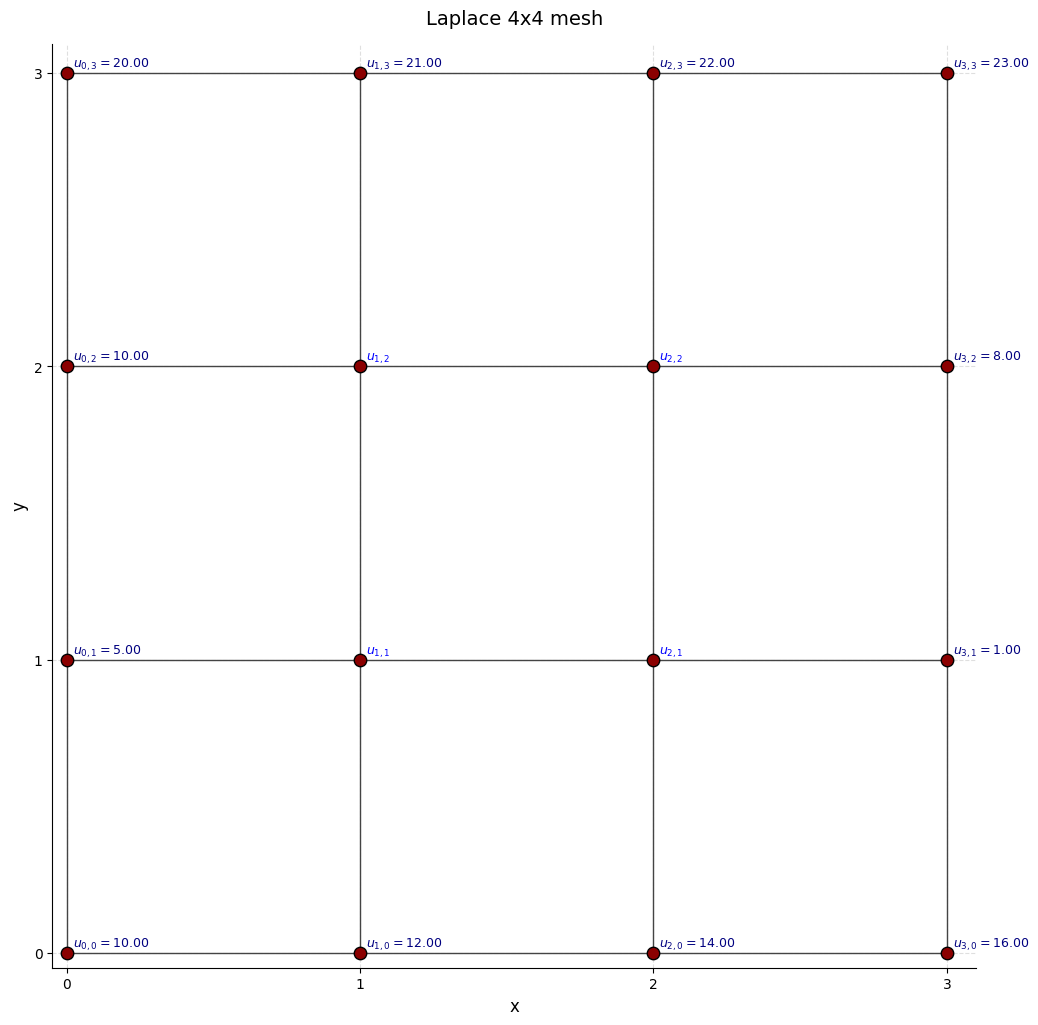

u array (i rows, j cols):
 [[10.  5. 10. 20.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [16.  1.  8. 23.]]


In [20]:
# annotate, plot
plt.figure(figsize=(12, 12))
for xi in x:
    plt.plot([xi]*len(y), y, color='#444444', lw=1)
for yi in y:
    plt.plot(x, [yi]*len(x), color='#444444', lw=1)
plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

for j in range(4):
    for i in range(4):
        if i in [0, 3] or j in [0, 3]:
            # boundary nodes with values (math convention i=row, j=col)
            plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                     f'$u_{{{i},{j}}}={u[i, j]:.2f}$',
                     color='navy', fontsize=9, weight='bold')
        else:
            # interior nodes shown by label only (no computed values yet)
            plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                     f'$u_{{{i},{j}}}$',
                     color='blue', fontsize=9, weight='bold')

plt.title('Laplace 4x4 mesh', fontsize=14, pad=14)
plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
plt.axis('square')
plt.xlim(-0.05, 3.1); plt.ylim(-0.05, 3.1)
plt.xticks([0, 1, 2, 3], ['0', '1', '2', '3'])
plt.yticks([0, 1, 2, 3], ['0', '1', '2', '3'])
for k in ['top','right']:
    plt.gca().spines[k].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("u array (i rows, j cols):\n", u)